# ***Final Assignment: X-Ray images classification***
---
*   Meri Ferretti (10666970)
*   Diana Nigrisoli (10824967)
*   Laura Pozzi (10868694)

In this script our ***third approach*** will be illustrated.

The implementation of the last method started from the same initial dataset of the second approach. In this case we operated such that images were not all in the same radiological format but were equally distributed between the two categories (standard and negative). For doing so, we trasformed with a probability of 50% each image into its opposite, forcing the dataset to be composed, in a probabilistic way, by images equally distributed between the two formats. 

Regarding the training, we tried:
1.   Transfer learning + Fine tuning using EfficientNetB3 and a customized Fully Connected network


### Mounting | Importing | Seed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/AI_PROJECT

/content/drive/MyDrive/AI_PROJECT


In [ ]:
!pip install keras_ocr

In [ ]:
import os
import sys
import cv2
import math
import json
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
tfk = tf.keras
tfkl = tf.keras.layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import load_model,Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter, defaultdict
import matplotlib.patches as patches
from glob import glob
from PIL import Image
plt.rc('font', size=16) 
import keras_ocr
from functools import partial

In [ ]:
### Random seed for reproducibility
seed = 42   

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

## Creation of Dataset for option 3

N.B. ***We DO NOT recommend to run this section cause It could last a huge amount of time***

###   1 - Functions

In [ ]:
!pip install tqdm
from tqdm import tqdm

In [ ]:
### DEFINING ROIs COORDINATES #### 

img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

In [ ]:
### IMAGES COUPLES MANAGEMENT 

def division_per_n_pict(x,y,n_pict):
  return x[y==n_pict]  

#******************************************************************************

def create_patients_per_pict(patients_class):
  patients_list = []
  for sample in patients_class:
    patients_list.append(sample[:6])
  (list_pat_unique, counts_pat) = np.unique(patients_list, return_counts=True)

  pat_1pict = division_per_n_pict(list_pat_unique,counts_pat,1) 
  pat_2pict = division_per_n_pict(list_pat_unique,counts_pat,2) 

  return pat_1pict,pat_2pict

#******************************************************************************

def select_image_per_patient(list_image_class, list_patient_set):
  list_img_set = []
  for img in tqdm(list_image_class):
    for pat in list_patient_set:
      if (img[:6] == pat):
        list_img_set.append(img)
  return list_img_set

#******************************************************************************
def select_2images_per_patient(list_image_class, list_patient):
  list_img_set = []
  for img in tqdm(list_image_class):
    for pat in list_patient:
      if (img[:6] == pat):
        list_img_set.append(img)
  return list_img_set

#******************************************************************************

def check_noise_single(image):
    noisy = False

    roi1 = image[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size] 
    std1 = roi1.std()
    
    roi2 = image[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
    std2 = roi2.std()
  
    roi3 = image[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size] 
    std3 = roi3.std()
    
    roi4 = image[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
    std4 = roi4.std()

    roi5 = image[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size] 
    std5 = roi5.std()

    roi6 = image[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size] 
    std6 = roi6.std()

    if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
      noisy = True
    
    return noisy

#*******************************************************************************

def check_noise_couple(img1, img2, id1, id2):
  noisy_1 = check_noise_single(img1)
  if (noisy_1):
    return id1
  else: 
   noisy_2 = check_noise_single(img2)
   if (noisy_2):
    return id2
   else: 
    return 0


#*******************************************************************************
def check_negative(img1,img2, id1, id2):
  #computing img1 ROIs' means
  roi1_img1 = img1[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  mean1_img1 = roi1_img1.mean()
  
  roi2_img1 = img1[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  mean2_img1 = roi2_img1.mean()
 
  roi3_img1 = img1[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  mean3_img1 = roi3_img1.mean()
  
  roi4_img1 = img1[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  mean4_img1 = roi4_img1.mean()

  roi5_img1 = img1[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  mean5_img1 = roi5_img1.mean()

  roi6_img1 = img1[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  mean6_img1 = roi6_img1.mean() 

  #computing img2 ROIs' means
  roi1_img2 = img2[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  mean1_img2 = roi2_img1.mean()
  
  roi2_img2 = img2[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  mean2_img2 = roi2_img2.mean()
 
  roi3_img2 = img2[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  mean3_img2 = roi3_img2.mean()
  
  roi4_img2 = img2[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  mean4_img2 = roi4_img2.mean()

  roi5_img2 = img2[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  mean5_img2 = roi5_img2.mean()

  roi6_img2 = img1[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  mean6_img2 = roi6_img2.mean() 

  #summing all the means
  mean_tot_img1 = mean1_img1 + mean2_img1 + mean3_img1 + mean4_img1 + mean5_img1 + mean6_img1
  mean_tot_img2 = mean1_img2 + mean2_img2 + mean3_img2 + mean4_img2 + mean5_img2 + mean6_img2

  if (mean_tot_img1 > mean_tot_img2):
    #it means that the img1 has white background => img2 has black background
    return id2 
  
  else: 
    return id1



#******************************************************************************
def discard_negative_and_notnoisy(pat_2pict, data_class,img_class_dir):
  
  couple_images = select_2images_per_patient(data_class,pat_2pict) 
  #array of images, the first two should belong to the same patient and so on 

  i=0

  img_kept=[]

  while(i<len(couple_images)): #we select one couple at a time
    image_path_1 = os.path.join(img_class_dir,couple_images[i])
    image_path_2 =  os.path.join(img_class_dir,couple_images[i+1])
    image_1= cv2.imread(image_path_1)
    image_2= cv2.imread(image_path_2)

    #1. check the noise -function 'check_noise'
    #if one img is noiy keep it and discard the other 
    #if both are NOT nosy skip to step 2
    x = check_noise_couple(image_1, image_2, couple_images[i], couple_images[i+1])
    if(x!=0):
      img_kept.append(x)
    else:
      #2. check if one is the negative of the other - function 'check_negative'
      #keep the one that has black background 
      y=check_negative(image_1, image_2, couple_images[i], couple_images[i+1])
      img_kept.append(y)
      
    i+=2

  return img_kept



In [ ]:
# SPLITTING 
def split_perclass_random(imgs_class, train_ratio, val_ratio, test_ratio):
  
  train, remaining = train_test_split(imgs_class, test_size=1 - train_ratio, shuffle = True, random_state = seed)
  val, test = train_test_split(remaining, test_size=test_ratio/(test_ratio + val_ratio), shuffle = True,random_state = seed) 

  return train, val, test


In [ ]:
# LOAD IN NEW FOLDERS + REMOVE TEXT

def midpoint(x1, y1, x2, y2):
    x_mid = int((x1 + x2)/2)
    y_mid = int((y1 + y2)/2)
    return (x_mid, y_mid)

def inpaint_text(img, pipeline):
    prediction_groups = pipeline.recognize([img])
    mask = np.zeros(img.shape[:2], dtype="uint8")
    for box in prediction_groups[0]:
        x0, y0 = box[1][0]
        x1, y1 = box[1][1] 
        x2, y2 = box[1][2]
        x3, y3 = box[1][3] 
        
        x_mid0, y_mid0 = midpoint(x1, y1, x2, y2)
        x_mid1, y_mi1 = midpoint(x0, y0, x3, y3)
        
        thickness = int(math.sqrt( (x2 - x1)**2 + (y2 - y1)**2 ))
        
        cv2.line(mask, (x_mid0, y_mid0), (x_mid1, y_mi1), 255,    
        thickness)
        img = cv2.inpaint(img, mask, 7, cv2.INPAINT_NS)
                 
    return(img)

def remove_text(img_path, img_code, pipeline):
  img = cv2.imread(img_path)
  img_noText = inpaint_text(img, pipeline)
  fixed_dir='/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Images_fixed'
  new_path= os.path.join(fixed_dir,img_code)
  cv2.imwrite(new_path,img_noText)
  return new_path

def load_in_folder (source, destination, normal_set, pneumo_set, tube_set): 
  #destination is the train or val or test folder
  #normal_set, pneumo_set, tube_set could be reated to train, val or test sets
  pipeline = keras_ocr.pipeline.Pipeline()

  for f in tqdm(normal_set):
      path_old=source + '/' + 'Normal'+ '/' + f
      path_new=remove_text(path_old, f, pipeline)
      shutil.copy(source + '/' + 'Normal'+ '/' + f, destination + '/' + 'Normal'+ '/' + f )
  
  for f in tqdm(pneumo_set):
      path_old=source + '/' + 'Pneumonia'+ '/' + f
      path_new=remove_text(path_old, f, pipeline)
      shutil.copy(source + '/' + 'Pneumonia'+ '/' + f, destination + '/' + 'Pneumonia'+ '/' +  f )

  for f in tqdm(tube_set):
     path_old=source + '/' + 'Tuberculosis'+ '/' + f
     path_new=remove_text(path_old, f, pipeline)
     shutil.copy(source + '/' + 'Tuberculosis'+ '/' + f, destination + '/' + 'Tuberculosis'+ '/' + f )

  return

### 2 - Pipeline



0) Preparation of data

In [ ]:
### Loading resized images 
normal_dir = '/content/drive/MyDrive/AI_PROJECT/DataDivided_resized/Normal'
tube_dir = '/content/drive/My Drive/AI_PROJECT/DataDivided_resized/Tuberculosis'
pneumo_dir = '/content/drive/My Drive/AI_PROJECT/DataDivided_resized/Pneumonia'

In [ ]:
print('Normal:', len(os.listdir(normal_dir)))
print('Pneumonia:', len(os.listdir(pneumo_dir)))
print('Tuberculosis:', len(os.listdir(tube_dir)))

In [ ]:
labels = pd.read_csv('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/labels_train.csv')
labels_df = pd.DataFrame(labels)

y = labels_df["label"]
x = labels_df["file"]

y_array = y.to_numpy()
print(y_array.shape)
x_array = x.to_numpy()
print(x_array.shape)

In [ ]:
MAPPING = {
    "Normal": "N",
    "Pneumonia": "P",
    "Tuberculosis": "T",
}
print(MAPPING)

In [ ]:
def division_per_class(x,y,class_name,n_sample = None):
  return x[y==MAPPING[class_name]] 

normal = division_per_class(x_array,y_array,"Normal")
pneumo = division_per_class(x_array,y_array,"Pneumonia")
tube = division_per_class(x_array,y_array,"Tuberculosis")

1) Division by n of pict

In [ ]:
# 1.  Division by n of pict

normal_1pict,normal_2pict = create_patients_per_pict (normal)
tube_1pict,tube_2pict = create_patients_per_pict (tube)
pneumo_1pict,pneumo_2pict = create_patients_per_pict (pneumo)

2) Array 1picture: selection of the images given the name of the patient

In [ ]:
# 2. Array 1 pict: no trasformation, selection of the images given the name of the patient

normal_1pict_imgs = select_image_per_patient(normal,normal_1pict)
tube_1pict_imgs = select_image_per_patient(tube,tube_1pict)
pneumo_1pict_imgs = select_image_per_patient(pneumo,pneumo_1pict)

3) Array 2picture: selection of the right one among the 2 available

In [ ]:
# 3. In 2pict, selection of the right one: NO noise and NO white

normal_kept_2pict = discard_negative_and_notnoisy (normal_2pict, normal, normal_dir)
tube_kept_2pict = discard_negative_and_notnoisy (tube_2pict, tube, tube_dir)
pneumo_kept_2pict = discard_negative_and_notnoisy (pneumo_2pict, pneumo, pneumo_dir)


4) Union of the two array

In [ ]:
# 4. Union of the 2 array

normal_kept =  normal_kept_2pict + normal_1pict_imgs 
tube_kept = tube_kept_2pict + tube_1pict_imgs  
pneumo_kept = pneumo_kept_2pict + pneumo_1pict_imgs 

5) Splitting

In [ ]:
# 5. Train/Validation/Test

normal_train, normal_val, normal_test = split_perclass_random(normal_kept, 0.7, 0.2, 0.1)
pneumo_train, pneumo_val, pneumo_test = split_perclass_random(pneumo_kept, 0.7, 0.2, 0.1)
tube_train, tube_val, tube_test = split_perclass_random(tube_kept, 0.7, 0.2, 0.1)

6) Loading in new folders

In [ ]:
# 6. Folder creation

source = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized'
destionation = '/content/drive/My Drive/AI_PROJECT/Dataset_Option3'

train_dir=os.path.join(destionation,'Train')
test_dir=os.path.join(destionation,'Test')
val_dir=os.path.join(destionation,'Validation')

# load_in_folder(source,train_dir,normal_train,pneumo_train,tube_train)
# load_in_folder(source,test_dir,normal_test,pneumo_test,tube_test)
# load_in_folder(source,val_dir,normal_val,pneumo_val,tube_val)

##Image Data Generators

In [ ]:
# Directories 
train_dir = '/content/drive/MyDrive/AI_PROJECT/Dataset_Option3/Train'
val_dir = '/content/drive/MyDrive/AI_PROJECT/Dataset_Option3/Validation'
test_dir = '/content/drive/MyDrive/AI_PROJECT/Dataset_Option3/Test'

In [ ]:
### Defining ROIs coordinates
img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

In [ ]:
######### PRE_PROCESSING FUNCTIONS ######## 
def equalize(image):
  grayimg = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  grayimg = np.uint8(grayimg)

  # Equalizing each channel individually
  image_eq = cv2.equalizeHist(grayimg)
 
  # Stacking the equalized channels back into a single image
  image_equal = np.stack((image_eq,image_eq,image_eq), axis=2)

  return image_equal
  
# *******************************************
def check_noise_single(img):
  noisy = False
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std1 = roi1.std()
  
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std2 = roi2.std()
 
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  std3 = roi3.std()
  
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  std4 = roi4.std()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  std5 = roi5.std()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  std6 = roi6.std()

  if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
    noisy = True
    
  return noisy
  
# *******************************************    
def filter_function(image):
  noisy = check_noise_single(image)
  if noisy :
    image_filt = cv2.medianBlur(image, 5)
    image_equal = equalize(image_filt)
    return image_equal
  else: 
    image_equal = equalize(image)
    return image_equal

# *******************************************
def opposite_contrast(image):
   return  abs(255-image)

# *******************************************
def change_with_probability(image,threshold):
  prob = random.random()
  if prob > threshold:
    image = opposite_contrast(image)
  return image 

# *******************************************
def apply_transf_gen (image):
  params = transforms_gen.get_random_transform(image.shape)
  x = transforms_gen.apply_transform(image, params)
  return x

############# final pre-processing functions ########

def preprocessing_funct_train(image):
  image = change_with_probability(image,0.5)
  image = filter_function(image)
  image = apply_transf_gen(image)

  return image

def preprocessing_funct(image):
  image = filter_function(image)
  return image

In [ ]:
img_height = 256
img_width = 256
batch_size = 64

from tensorflow.keras.preprocessing.image import ImageDataGenerator

transforms_gen = ImageDataGenerator(
    fill_mode = 'constant',
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    horizontal_flip = True,
    zoom_range = 0.1,
)

### Image augmentation on training dataset only
train_datagen = ImageDataGenerator(
    preprocessing_function= preprocessing_funct_train
    ) 

validation_datagen = ImageDataGenerator(
    preprocessing_function= preprocessing_funct
    )

test_datagen = ImageDataGenerator(
    preprocessing_function= preprocessing_funct
    )


### Online importing
train_dataset = train_datagen.flow_from_directory(
    directory = train_dir,
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = True) 

validation_dataset = validation_datagen.flow_from_directory(
    directory = val_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

test_dataset = test_datagen.flow_from_directory(
    directory = test_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

Found 8458 images belonging to 3 classes.
Found 2417 images belonging to 3 classes.
Found 1211 images belonging to 3 classes.


##Training

### 1 - Functions

In [ ]:
###### MODEL DEFINITION ######
tfk = tf.keras
tfkl = tf.keras.layers
### Preprocessing to be applied to the input images
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_feat_extractor (img_height: int, img_width: int) -> tf.keras.Model:
    ## network: features extractor
    net = tfk.applications.EfficientNetB3(
          include_top = False,
          weights = "imagenet", 
          input_shape = (img_height, img_width, 3)
          ) 
    net.trainable = False 
    return net 

def build_model(feat_extractor,img_height,img_width,num_classes) -> tf.keras.Model:
    # input of the model
    inputs = tfk.Input(shape=(img_height,img_width,3))

    x = preprocess_input(inputs)
    x = feat_extractor(x, training = False)

    # Classificator: rebuild top
    dropout_rate = 0.4
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    x = tfkl.GlobalAveragePooling2D()(x)
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    x = tfkl.Dense(
        256, 
        activation='relu',
        kernel_initializer = tfk.initializers.HeUniform(seed)
    )(x)
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    outputs = tfkl.Dense(
              num_classes, 
              activation='softmax',
              kernel_initializer = tfk.initializers.GlorotUniform(seed),
              kernel_regularizer = tfk.regularizers.L2(0.01),
              #bias_initializer=lambda _, dtype: tf.convert_to_tensor(freqs, dtype=dtype)
    )(x)

    # Connecting input and output through the Model class
    model = tfk.Model(inputs=inputs, outputs=outputs, name='model')

    return model


### MODEL COMPILE
def model_compile (model, learn_rate) ->None:
    optimizer=tfk.optimizers.Adam(learning_rate = learn_rate)
    model.compile(
          loss=tfk.losses.CategoricalCrossentropy(), 
          optimizer= optimizer,
          metrics='accuracy'
    )



In [ ]:
###### METRICS DEFINITION #######

def plot_history(history):
    hist = history
    plt.figure(figsize=(15, 5))
    plt.plot(hist["accuracy"], label="Training", alpha=0.8, color="#ff7f0e")
    plt.plot(hist["val_accuracy"], label="Validation", alpha=0.8, color="#4D61E2")
    plt.ylim(0, 1)
    plt.title("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    plt.figure(figsize=(15, 5))
    plt.plot(hist["loss"], label="Training", alpha=0.8, color="#ff7f0e")
    plt.plot(hist["val_loss"], label="Validation", alpha=0.8, color="#4D61E2")
    plt.title("loss")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()

def evaluate(model: tf.keras.Model,dataset) -> None:
    predictions = model.predict(dataset)

    y_test = dataset.classes
    pred_number = np.argmax(predictions, axis=-1)
    compute_metrics(y_test, pred_number)


def compute_metrics(y_test, pred_number):
  
    # Computing confusion matrix
    cm = confusion_matrix(y_test, pred_number)

    # Computing classification metrics
    accuracy = accuracy_score(y_test, pred_number)
    precision = precision_score(y_test, pred_number, average='macro')
    recall = recall_score(y_test, pred_number, average='macro')
    f1 = f1_score(y_test, pred_number, average='weighted')

    # Printing classification metrics
    print('Accuracy:',accuracy.round(4))
    print('Precision:',precision.round(4))
    print('Recall:',recall.round(4))
    print('F1:',f1.round(4))

    # Plotting confusion matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm.T, xticklabels=list(train_dataset.class_indices), yticklabels=list(train_dataset.class_indices), annot=True)
    plt.xlabel('True labels')
    plt.ylabel('Predicted labels')
    plt.show()

    print(classification_report(y_test, pred_number, target_names=labels))


### 2 - Transfer Learning

In [ ]:
### Model definition

#Defining the CNN: EfficientNetB3
net = build_feat_extractor(img_height, img_width)

#Building model structure
tl_model = build_model(net,img_height,img_width,CLASSES)

tl_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb3 (Functional)  (None, 8, 8, 1536)       10783535  
                                                                 
 dropout (Dropout)           (None, 8, 8, 1536)        0         
                                                                 
 global_average_pooling2d (G  (None, 1536)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_1 (Dropout)         (None, 1536)              0         
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                             

In [ ]:
### Model Compiling

lear_rate_tl = 1e-3
model_compile(tl_model,lear_rate_tl)

In [ ]:
## class weights
from collections import Counter
counter = Counter(train_dataset.classes)
number_classes = 3                          

n_samples = float(sum(counter.values()))       

class_weights = {class_id : n_samples/(num_images) for class_id, num_images in counter.items()}                     

print(counter.values())
print(class_weights)


dict_values([5124, 2313, 1021])
{0: 1.650663544106167, 1: 3.6567228707306527, 2: 8.284035259549462}


In [ ]:
### Model fitting 

# Defining callbacks (early stopping) to be used in the Transfer Learning part
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/AI_PROJECT/models/Opt3_NoLetters_tl/weights_improvement_{epoch:02d}_{val_accuracy:.2f}', 
        monitor='val_accuracy', save_best_only=True, save_weights_only=False, 
        mode='max'),
    tfk.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', patience=5, factor=0.5, min_lr=1e-9)
]

# Fitting the model on our training dataset
history_tl = tl_model.fit(
    x = train_dataset,
    epochs = 40, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_tl, 
    class_weight =  class_weights
).history


In [ ]:
### Loading the best model from the Transfer Learning part 
tl_model = tfk.models.load_model('/content/drive/My Drive/AI_PROJECT/tl_models_opt3/best_model_opt3')

In [ ]:
### PREDICTION on validation set - just to check the correct upload
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(tl_model, validation_dataset)

In [ ]:
### PREDICTION on test set
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(tl_model, test_dataset)

### 3 - Fine Tunining

In [ ]:
### FINE TUNING ####
ft_model = tl_model
ft_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb3 (Functional)  (None, 8, 8, 1536)       10783535  
                                                                 
 dropout (Dropout)           (None, 8, 8, 1536)        0         
                                                                 
 global_average_pooling2d (G  (None, 1536)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_1 (Dropout)         (None, 1536)              0         
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                             

In [ ]:
ft_model.get_layer('efficientnetb3').trainable = True
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers):
   print(i, layer.name, layer.trainable)

In [ ]:
# Freeze first N layers,
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers[:118]):
   layer.trainable=False
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers):
   print(i, layer.name, layer.trainable)

In [ ]:
initial_learning_rate=1e-5
model_compile(ft_model,initial_learning_rate)

In [ ]:
### Model fitting 

# Defining callbacks (early stopping) to be used in the Transfer Learning part
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/AI_PROJECT/models/Opt3_NoLetters_ft/weights_improvement_{epoch:02d}_{val_accuracy:.2f}.h5', 
        monitor='val_accuracy', save_best_only=True, save_weights_only=False, 
        mode='max'),
    tfk.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', patience=5, factor=0.5, min_lr=1e-9)
]

# Fitting the model on our training dataset
history_ft = ft_model.fit(
    x = train_dataset,
    epochs = 200, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_tl, 
    class_weight =  class_weights
).history


### 4 -  Evaluation

In [ ]:
best_model = tf.keras.models.load_model('/content/drive/My Drive/AI_PROJECT/models/Opt3_NoLetters_ft/weights_improvement_25_0.94.h5')

In [ ]:
labels = ['Normal','Pneumonia','Tuberculosis']

38/38 [==============================] - 13s 329ms/step
Accuracy: 0.9392
Precision: 0.9084
Recall: 0.9165
F1: 0.9394


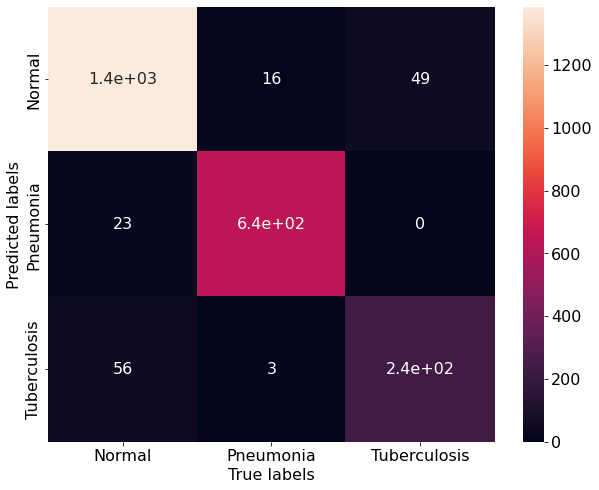

              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      1464
   Pneumonia       0.97      0.97      0.97       661
Tuberculosis       0.80      0.83      0.82       292

    accuracy                           0.94      2417
   macro avg       0.91      0.92      0.91      2417
weighted avg       0.94      0.94      0.94      2417



In [ ]:
### EVALUETION on validation dataset

evaluate(best_model,validation_dataset)

19/19 [==============================] - 744s 41s/step
Accuracy: 0.9389
Precision: 0.9155
Recall: 0.9129
F1: 0.939


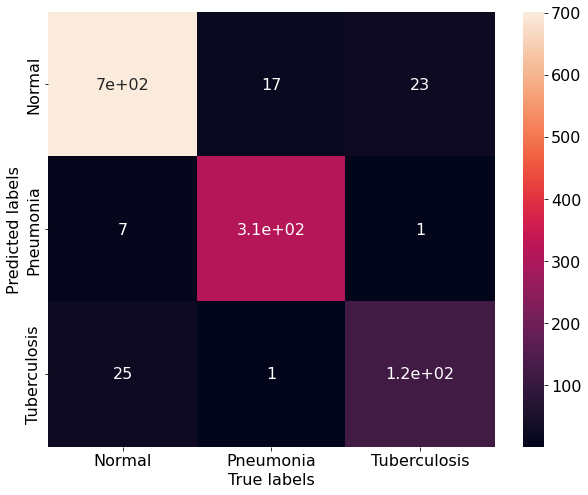

              precision    recall  f1-score   support

      Normal       0.95      0.96      0.95       733
   Pneumonia       0.98      0.95      0.96       331
Tuberculosis       0.83      0.84      0.83       147

    accuracy                           0.94      1211
   macro avg       0.92      0.91      0.91      1211
weighted avg       0.94      0.94      0.94      1211



In [ ]:
### EVALUATION on test dataset

evaluate(best_model,test_dataset)

### 5 - TTA

In [ ]:
# Insert here the path of the model which you would like to apply the TTA to 
path = '/content/drive/My Drive/AI_PROJECT/models/Opt3_NoLetters_ft/weights_improvement_25_0.94.h5'

In [ ]:
img_height = 256
img_width = 256
batch_size = 64

test_datagen_tta = ImageDataGenerator()
val_datagen_tta = ImageDataGenerator()

val_dataset_tta = val_datagen_tta.flow_from_directory(
    directory = val_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False)

test_dataset_tta = test_datagen_tta.flow_from_directory(
    directory = test_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False)

Found 2417 images belonging to 3 classes.
Found 1211 images belonging to 3 classes.


In [ ]:
def apply_Zoom (image):
  params = ZoomShift_gen.get_random_transform(image.shape)
  x = ZoomShift_gen.apply_transform(image, params)
  return x

def apply_Flip (image):
  params = Flip_gen.get_random_transform(image.shape)
  x = Flip_gen.apply_transform(image, params)
  return x

############# final pre-processing function ########
def preprocessing_funct_Opposite(image):
  image = opposite_contrast(image)
  image = filter_function(image)
  return image

def preprocessing_funct_Zoom(image):
  image = filter_function(image)
  image = apply_Zoom(image)
  return image

def preprocessing_funct_Flip(image):
  image = filter_function(image)
  image = apply_Flip(image)
  return image



In [ ]:
ZoomShift_gen = ImageDataGenerator(
    fill_mode = 'constant',
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.1,
)

Flip_gen = ImageDataGenerator(
    horizontal_flip=True
)

In [ ]:
class AugmentedModel:
    def __init__(self, original_model) -> None:
        self.model = tf.keras.models.load_model(path)
        #self.model = original_model

        self.augmentations = {
            "None": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  filter_function
            ),
            "Filter+Opposite": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  preprocessing_funct_Opposite
            ),
            "Flip": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  preprocessing_funct_Flip
            ),
            "ZoomShift": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  preprocessing_funct_Zoom
            ),
        }

    def predict(self, X):
        preds_tta = []

        for name, aug in self.augmentations.items():
            x = aug.flow(X, shuffle = False)
            preds = self.model.predict(x, verbose=False)
            preds_tta.append(preds)

        out = np.mean(preds_tta, axis=0)
        out = tf.argmax(out, axis=-1)

        return out

Accuracy: 0.9456
Precision: 0.9163
Recall: 0.9238
F1: 0.9458


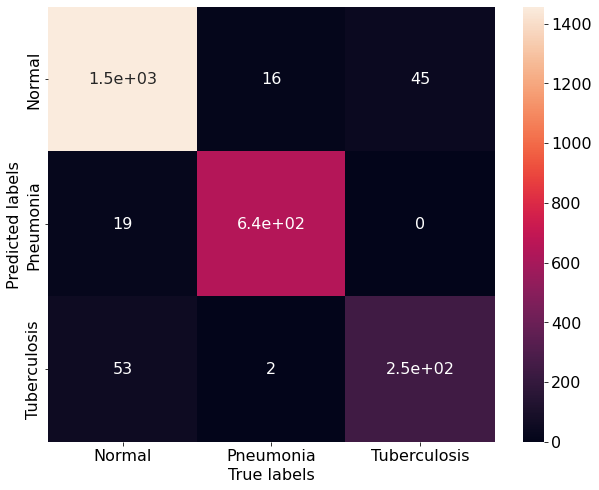

              precision    recall  f1-score   support

      Normal       0.96      0.95      0.96      1528
   Pneumonia       0.97      0.97      0.97       661
Tuberculosis       0.82      0.85      0.83       292

    accuracy                           0.95      2481
   macro avg       0.92      0.92      0.92      2481
weighted avg       0.95      0.95      0.95      2481



In [ ]:
## TTA on VALIDATION SET
M = AugmentedModel(path)

# Validation set
idx = len(val_dataset_tta)
all_preds = []
all_labs = []
for (X, y) in val_dataset_tta:
    all_preds.extend(M.predict(X))
    all_labs.extend(tf.argmax(y, axis=-1))
    idx -= 1
    print("|" + "#"*(len(val_dataset_tta) - idx) + " "*(idx + 1) + "|", end="\r")
    if idx < 0:
        break

labels = ['Normal','Pneumonia','Tuberculosis']
compute_metrics(all_labs, all_preds)

Accuracy: 0.9482
Precision: 0.9255
Recall: 0.9253
F1: 0.9483


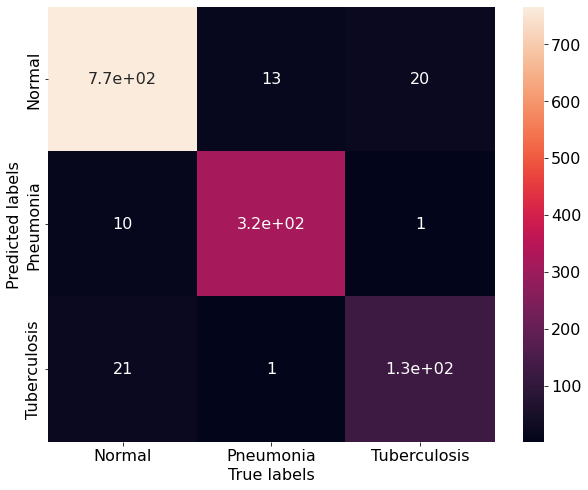

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       797
   Pneumonia       0.97      0.96      0.96       331
Tuberculosis       0.85      0.86      0.85       147

    accuracy                           0.95      1275
   macro avg       0.93      0.93      0.93      1275
weighted avg       0.95      0.95      0.95      1275



In [ ]:
## TTA on TEST SET 
M = AugmentedModel(path)

# Test set
idx = len(test_dataset_tta)
all_preds = []
all_labs = []cv2
for (X, y) in test_dataset_tta:
    all_preds.extend(M.predict(X))
    all_labs.extend(tf.argmax(y, axis=-1))
    idx -= 1
    print("|" + "#"*(len(test_dataset_tta) - idx) + " "*(idx + 1) + "|", end="\r")
    if idx < 0:
        break

labels = ['Normal','Pneumonia','Tuberculosis']
compute_metrics(all_labs, all_preds)